In [13]:
from PIL import Image
from IPython.display import display

### Install smudgeplot

In [7]:
! pip install smudgeplot==0.5.3b0 # pip install -e .

### Check it works

In [16]:
! smudgeplot --help

usage: 
            smudgeplot <task> [options]

            tasks: cutoff            Calculate meaningful values for lower kmer histogram cutoff.
                   hetmers           Calculate unique kmer pairs from a FastK k-mer database.
                   peak_aggregation  Agregates smudges using local aggregation algorithm; prints assignments to stdout.
                   plot              Generate 2d histogram; infer ploidy and plot a smudgeplot.
                   all               Runs all the steps (with default options)
                   extract           Extract kmer pair sequences from a FastK k-mer database.
            

positional arguments:
  task           Task to execute; for task specific options execute smudgeplot
                 <task> -h

options:
  -h, --help     show this help message and exit
  -v, --version  Print the version and exit.


### Download data

In [3]:
! wget ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR326/001/SRR3265401/SRR3265401_1.fastq.gz
! wget ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR326/001/SRR3265401/SRR3265401_2.fastq.gz

### Move them to a reasonable place

In [6]:
! mkdir -p data/Scer
! mv *fastq.gz data/Scer/

### Run FastK to create a k-mer database

In [1]:
! FastK -v -t4 -k31 -M16 -T4 data/Scer/SRR3265401_[12].fastq.gz -Ndata/Scer/FastK_Table


Using 2 threads to read 2 fastq files some or all of which are compressed

Determining minimizer scheme & partition for FastK_Table
  Estimate 0.848G 31-mers
  Handling data in a single block
  Using 5-minimizers with 1024 core prefixes

Phase 1: Partitioning K-mers into 2 Super-mer Files

  There are 13,075,986 reads totalling 1,278,223,010 bps

     Part:       31-mer  super-mers  ave. length
        0:  885,923,194  82,130,978         10.8
      Sum:  885,923,194  82,130,978         10.8

      Range 885,923,194 - 885,923,194 (0.00%)

  Resources for phase:  27.073u  0.724s  16.497w  168.5%

Phase 2: Sorting & Counting K-mers in 1 blocks

      Part:  wgt'd k-mers  savings             
         0:   179,662,517      4.9
       All:   179,662,517      4.9

  Resources for phase:  13.501u  1.260s  4.683w  315.2%

Phase 3 (-t option): Merging K-mer Table Parts

  There are 14,053,635 31-mers that occur 4-or-more times

  The table occupies 112.95 MB

  Resources for phase:  0.112u  0.

### Find all k-mer pairs in the dataset by running smudgeplot's hetmer task.
### This generates the `data/Scer/kmerpairs_text.smu` file.
### It's a flat file with three columns; covB, covA and freq (the number of k-mer pairs with these respective coverages).

In [8]:
! smudgeplot hetmers -L 12 -t 4 -o data/Scer/kmerpairs --verbose data/Scer/FastK_Table

Running smudgeplot v0.5.3
Task: hetmers
Calling: hetmers  -odata/Scer/kmerpairs -e12 -T4 -v data/Scer/FastK_Table

  The input table is untrimmed and not symmetric

  Trimming k-mers in table with count < 12

  Making trimmed table symmetric

  Starting to count covariant pairs

  Count complete, outputting table


### Use the .smu file to infer ploidy and create smudgeplot

In [19]:
! smudgeplot all -o data/Scer/trial_run data/Scer/kmerpairs.smu -ylim 85

Running smudgeplot v0.5.3
Task: all

Loading data

Masking errors using local aggregation algorithm
K-mer Statistics:
  Total k-mers: 2,779,100
  Genomic k-mers: 2,432,604
  Error k-mers: 346,496 (12.47%)
  K-mers in smudges: 2,094,905 (86.12%)

Inferring 1n coverage using grid algorithm
Best coverage to precision of 1/10: 14.90
Best coverage to precision of 1/100: 14.18
Best coverage to precision of 1/100 (just to be sure): 14.18

Creating centrality plot

Inferred coverage: 14.180

Creating smudge report
Detected smudges / sizes:
  ['AAAB', 'AABB']
  [1210558, 884347]
Written smudge report to: data/Scer/trial_run.smudge_report.tsv

Creating smudgeplots


In [20]:
!ls data/Scer/

FastK_Table.hist               trial_run_centralities.txt
FastK_Table.ktab               trial_run_smudgeplot_log10.png
kmerpairs.smu                  trial_run_smudgeplot.png
SRR3265401_1.fastq.gz          trial_run.sma
SRR3265401_2.fastq.gz          trial_run.smudge_report.tsv
trial_run_centralities.png


### View smudgeplot

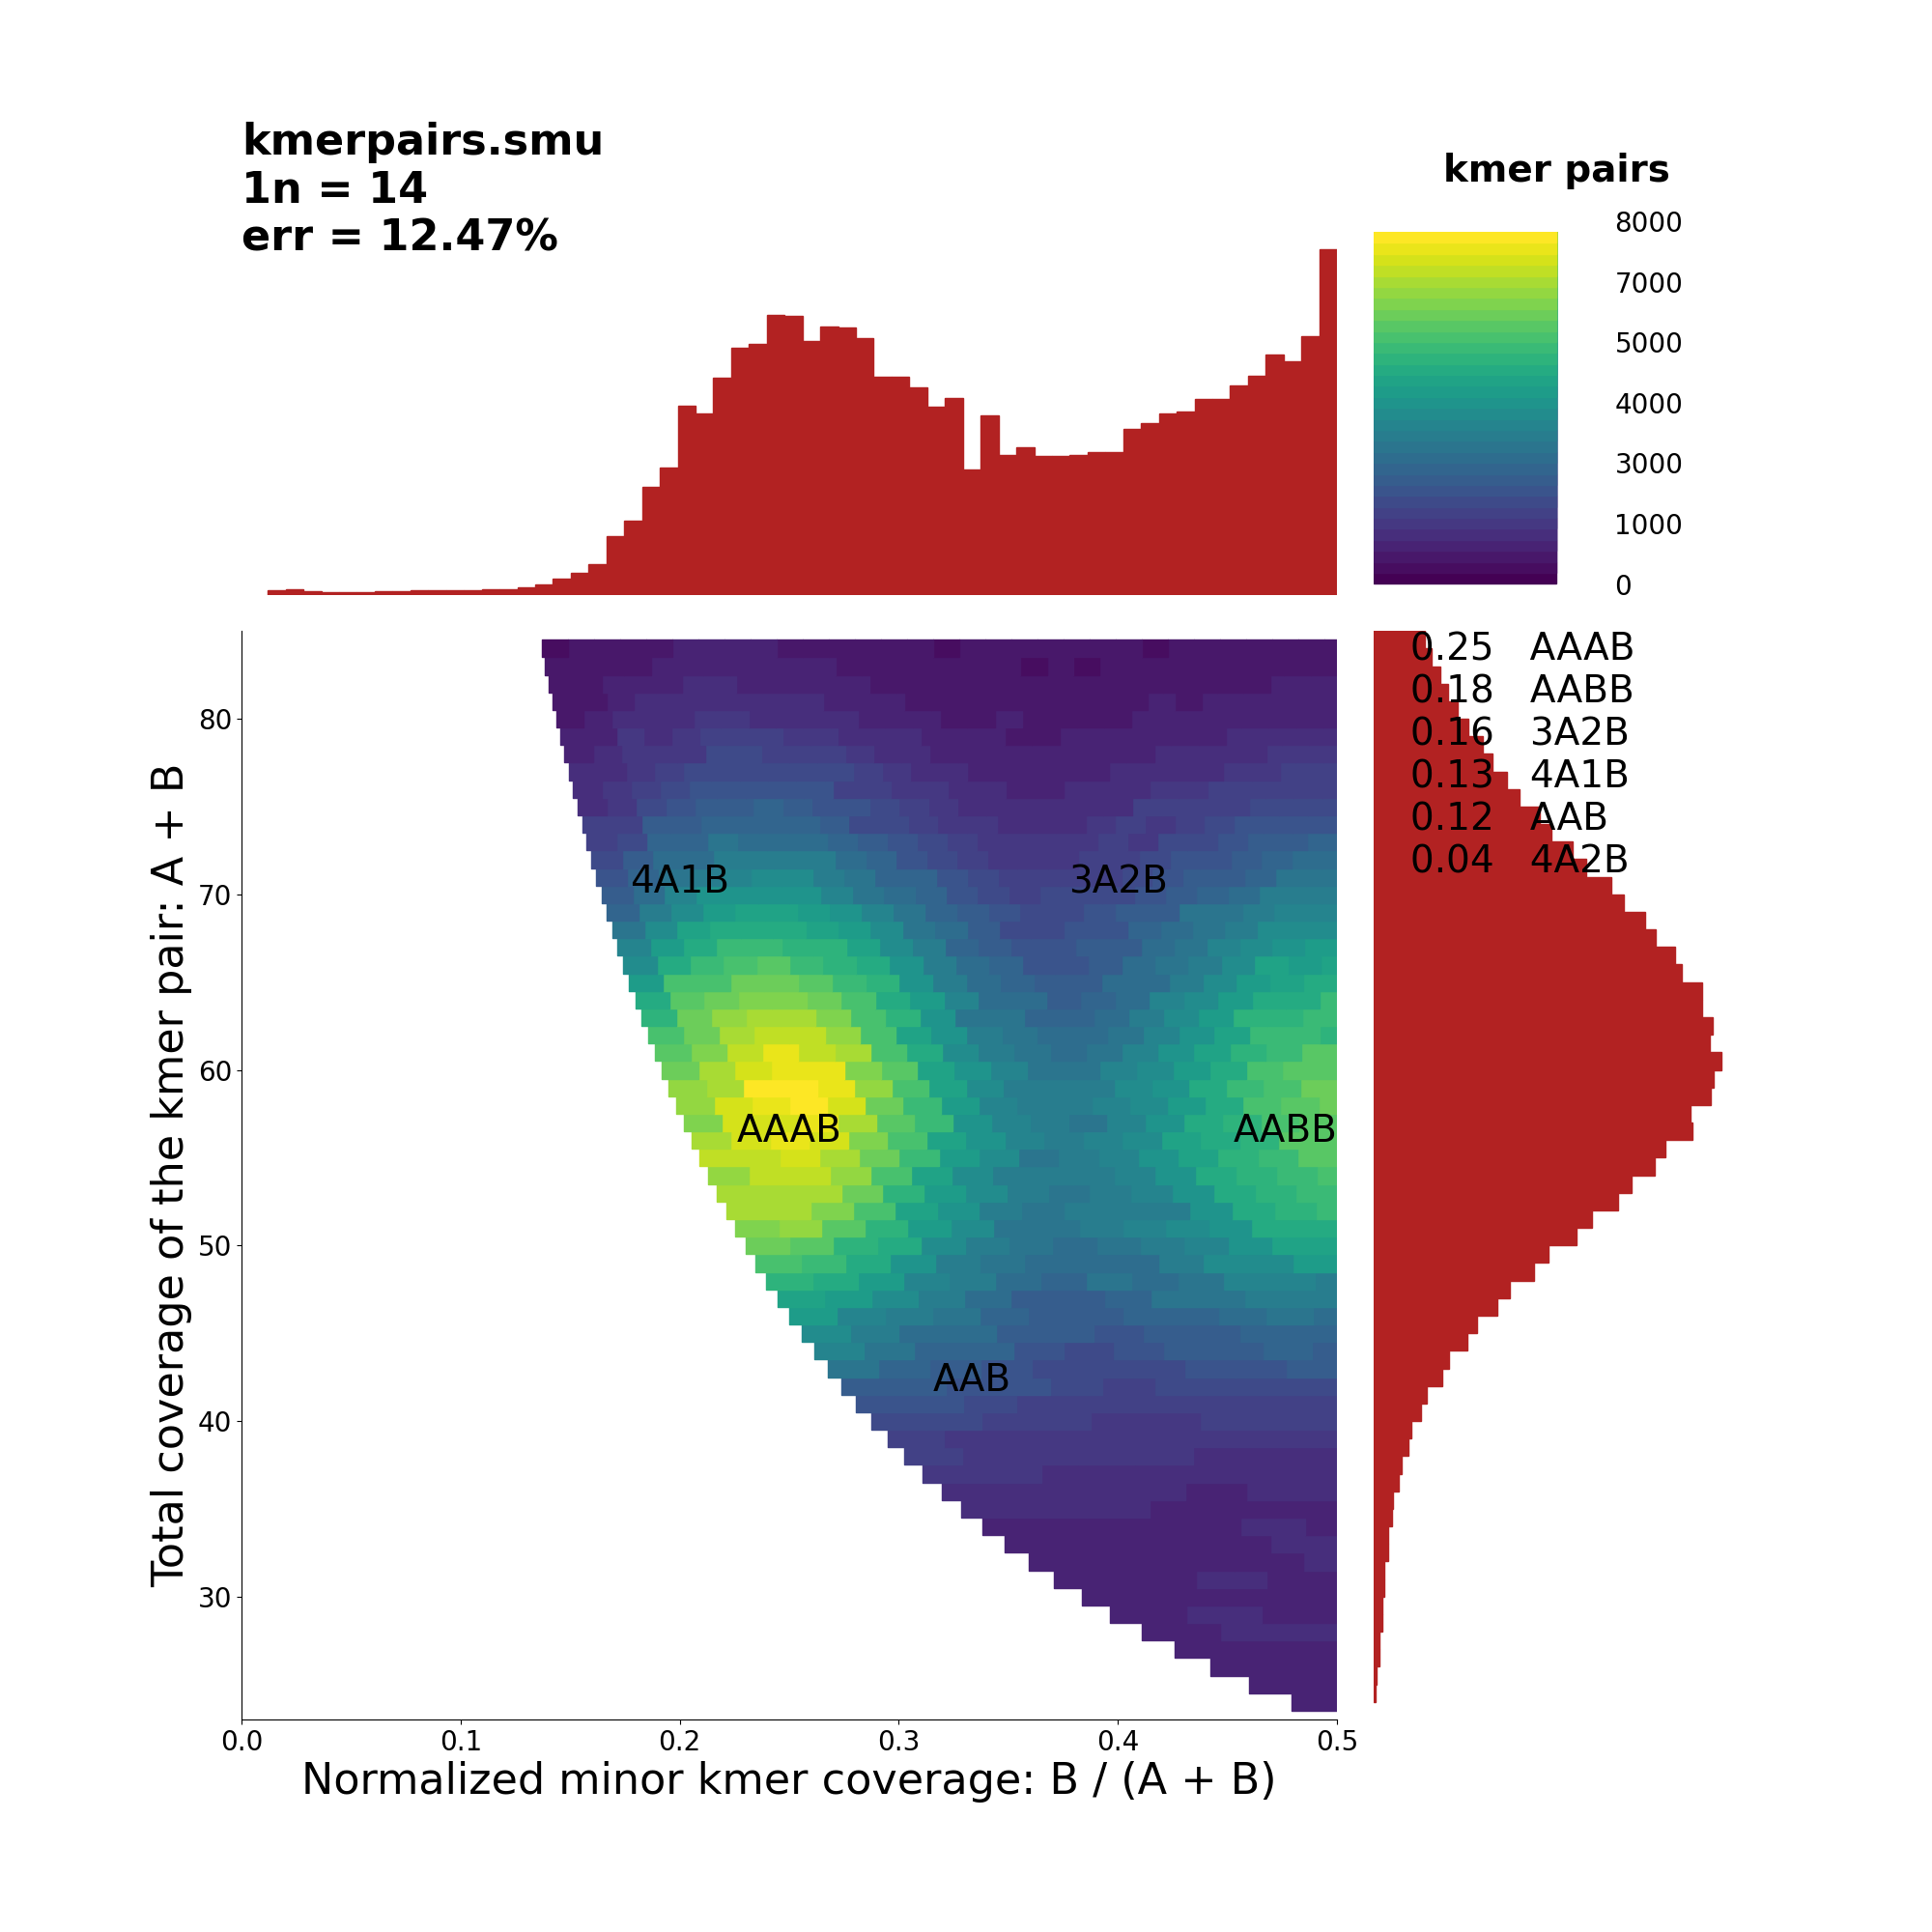

In [21]:
smudgeplot = Image.open('data/Scer/trial_run_smudgeplot.png')
display(smudgeplot)